# Лабораторна робота №3 Візуалізація даних
## Завдання 1. Обрати унікальний датасет з https://archive.ics.uci.edu/datasets

Я обрав Heart Disease

In [7]:
import pandas as pd
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df_heart = pd.read_csv(url, names=columns, na_values='?')
print(f"Розмір датасету: {df_heart.shape[0]} рядків та {df_heart.shape[1]} колонок\n")
display(df_heart.head())

Розмір датасету: 303 рядків та 14 колонок



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Завдання 2. Здійснити Data Cleaning

In [8]:
print("Діагностика до очищення")
missing_data = df_heart.isnull().sum()
print("Колонки з пропущеними значеннями:")
display(missing_data[missing_data > 0])
duplicates_count = df_heart.duplicated().sum()
print(f"\nЗнайдено повних дублікатів: {duplicates_count}")
print("\nОчищення")
df_clean = df_heart.copy()
for col in ['ca', 'thal']:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)
    print(f"Пропуски в колонці '{col}' заповнено значенням: {median_value}")
if duplicates_count > 0:
    df_clean = df_clean.drop_duplicates()
    print("Дублікати успішно видалено.")
else:
    print("Дублікатів не знайдено, пропускаємо видалення.")
print("\nРезультат")
print(f"Залишилось пропусків: {df_clean.isnull().sum().sum()}")
print(f"Фінальний розмір: {df_clean.shape[0]} рядків та {df_clean.shape[1]} колонок")
display(df_clean.dtypes)

Діагностика до очищення
Колонки з пропущеними значеннями:


ca      4
thal    2
dtype: int64


Знайдено повних дублікатів: 0

Очищення
Пропуски в колонці 'ca' заповнено значенням: 0.0
Пропуски в колонці 'thal' заповнено значенням: 3.0
Дублікатів не знайдено, пропускаємо видалення.

Результат
Залишилось пропусків: 0
Фінальний розмір: 303 рядків та 14 колонок


age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

## Завдання 3. Побудова графіків залежності
Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).


Візуалізація залежностей між атрибутами


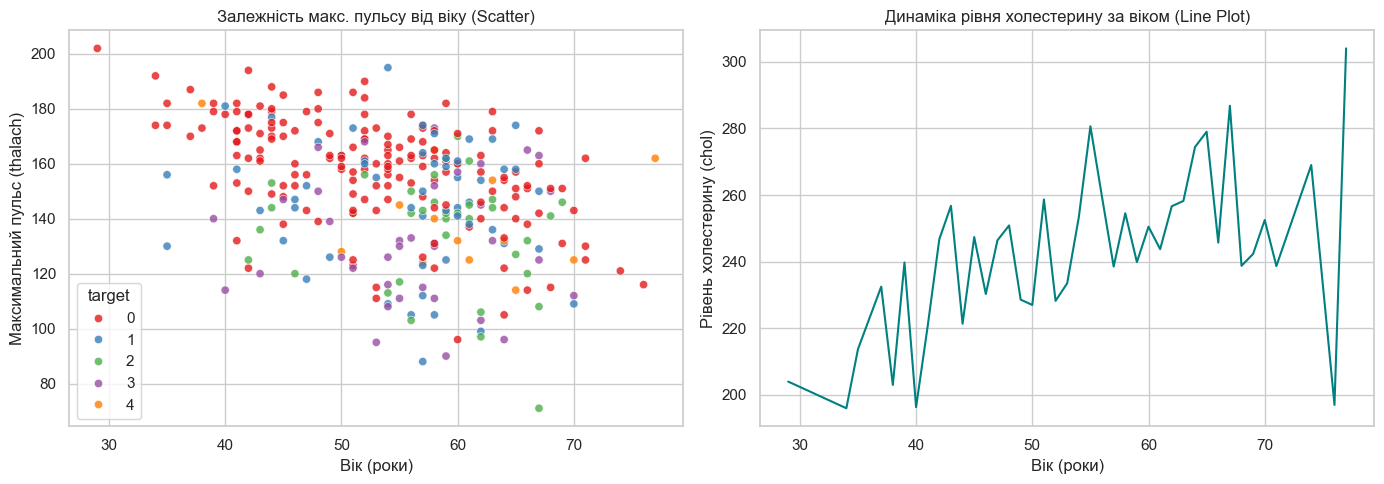

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Візуалізація залежностей між атрибутами")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=df_clean, 
    x='age', 
    y='thalach', 
    hue='target', 
    palette='Set1', 
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title("Залежність макс. пульсу від віку (Scatter)")
axes[0].set_xlabel("Вік (роки)")
axes[0].set_ylabel("Максимальний пульс (thalach)")
sns.lineplot(
    data=df_clean, 
    x='age', 
    y='chol', 
    color='teal',
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Динаміка рівня холестерину за віком (Line Plot)")
axes[1].set_xlabel("Вік (роки)")
axes[1].set_ylabel("Рівень холестерину (chol)")
plt.tight_layout()
plt.show()

## Завдання 4. Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

Гістограма розподілу атрибута `age` (вік) по 5 заданим діапазонам.

Гістограма розподілу за віком


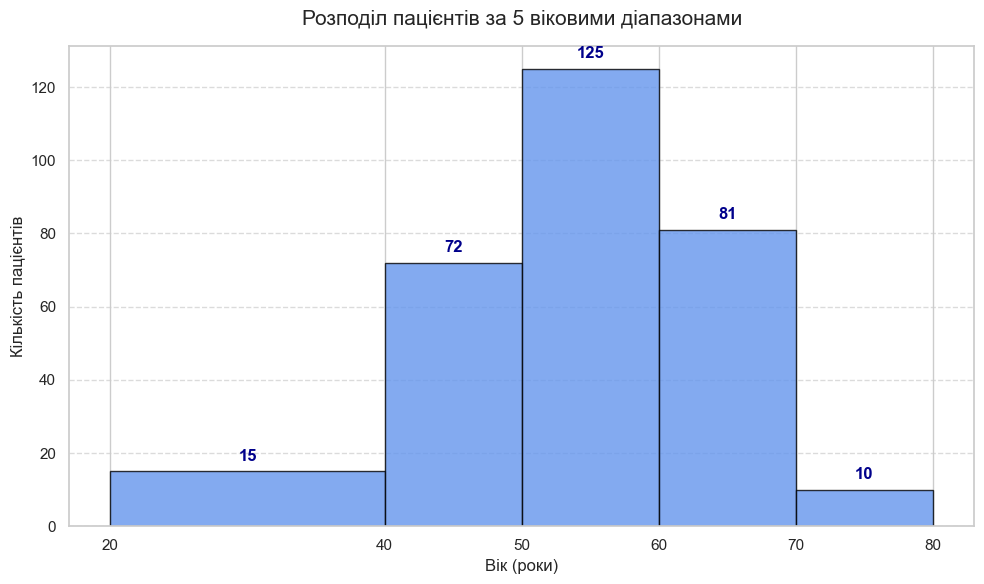

In [10]:
print("Гістограма розподілу за віком")
custom_bins = [20, 40, 50, 60, 70, 80]
plt.figure(figsize=(10, 6))
counts, edges, bars = plt.hist(
    df_clean['age'], 
    bins=custom_bins, 
    color='cornflowerblue', 
    edgecolor='black', 
    alpha=0.8
)
for count, rect in zip(counts, bars):
    height = rect.get_height()
    if height > 0: # Підписуємо тільки якщо там є дані
        plt.text(
            rect.get_x() + rect.get_width() / 2, 
            height + 2, 
            f'{int(count)}', 
            ha='center', 
            va='bottom', 
            fontsize=12,
            fontweight='bold',
            color='darkblue'
        )
plt.title('Розподіл пацієнтів за 5 віковими діапазонами', fontsize=15, pad=15)
plt.xlabel('Вік (роки)', fontsize=12)
plt.ylabel('Кількість пацієнтів', fontsize=12)
plt.xticks(custom_bins) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Завдання 5. Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 


Мистецтво багатовимірної візуалізації

1. Будуємо Pairplot


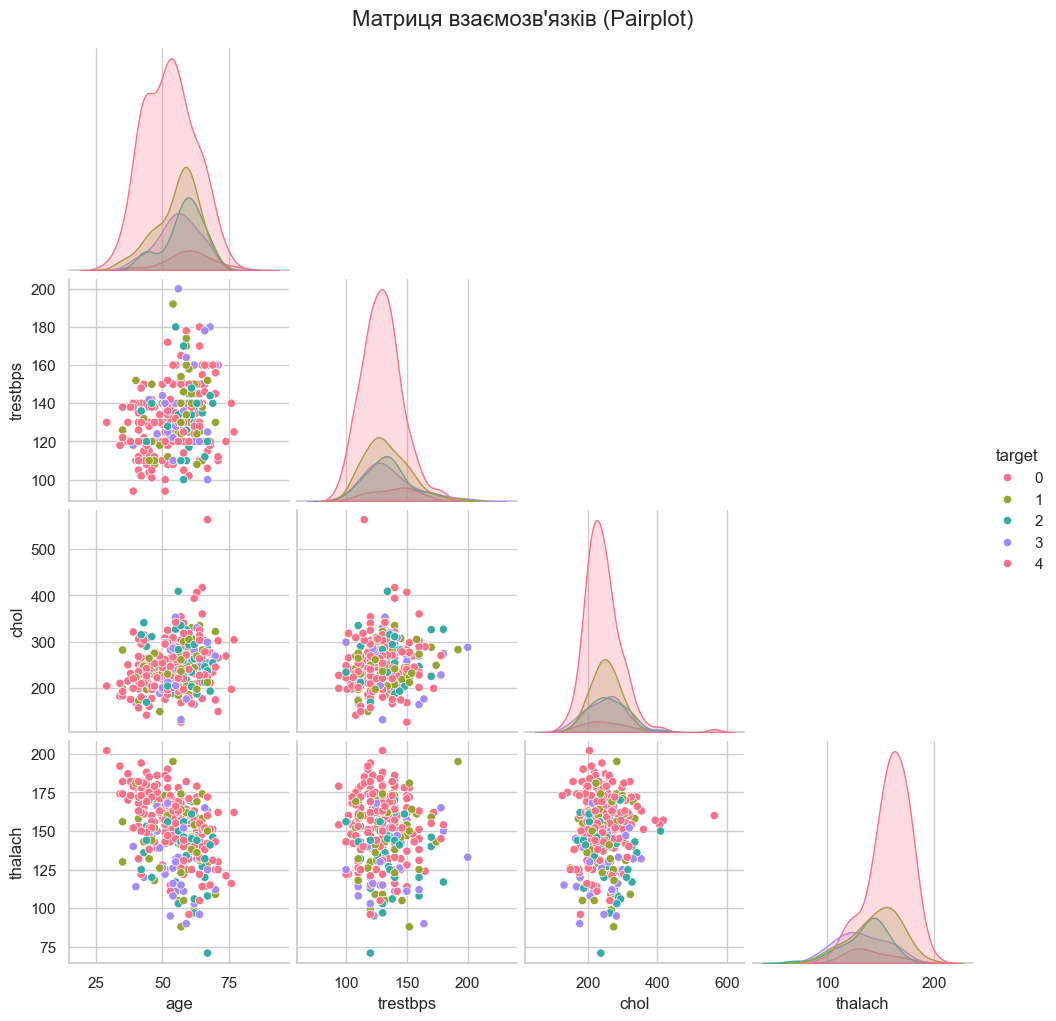


2. Будуємо 4D Scatter Plot


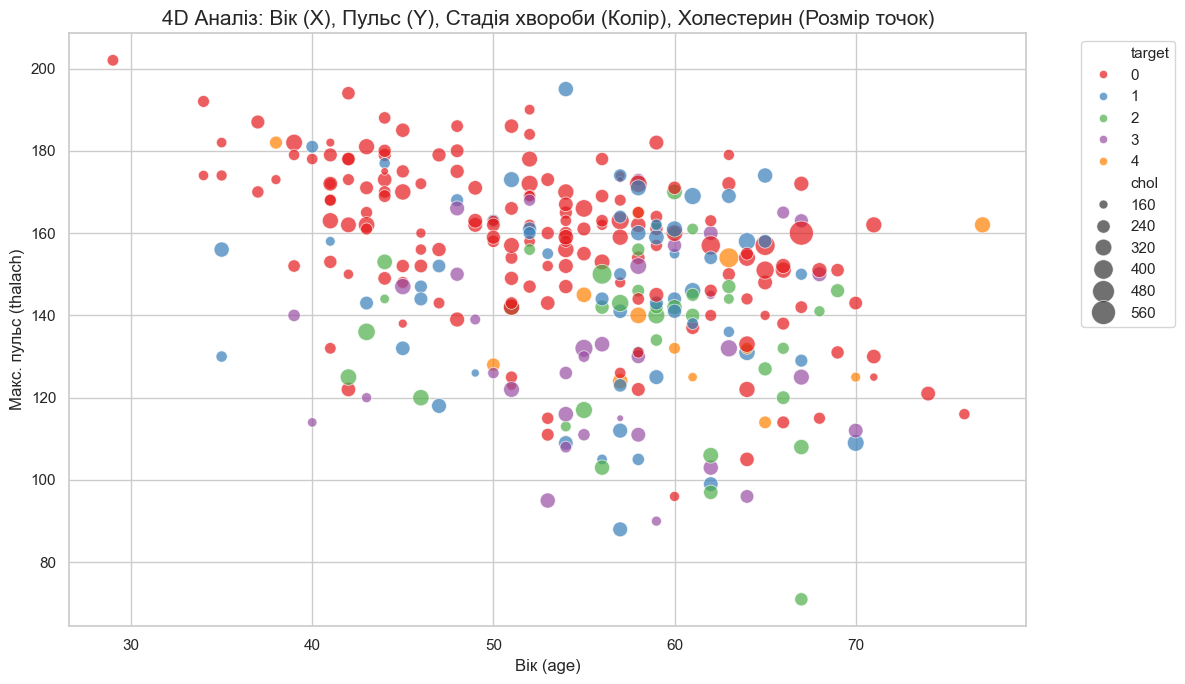


3. Будуємо 5D FacetGrid


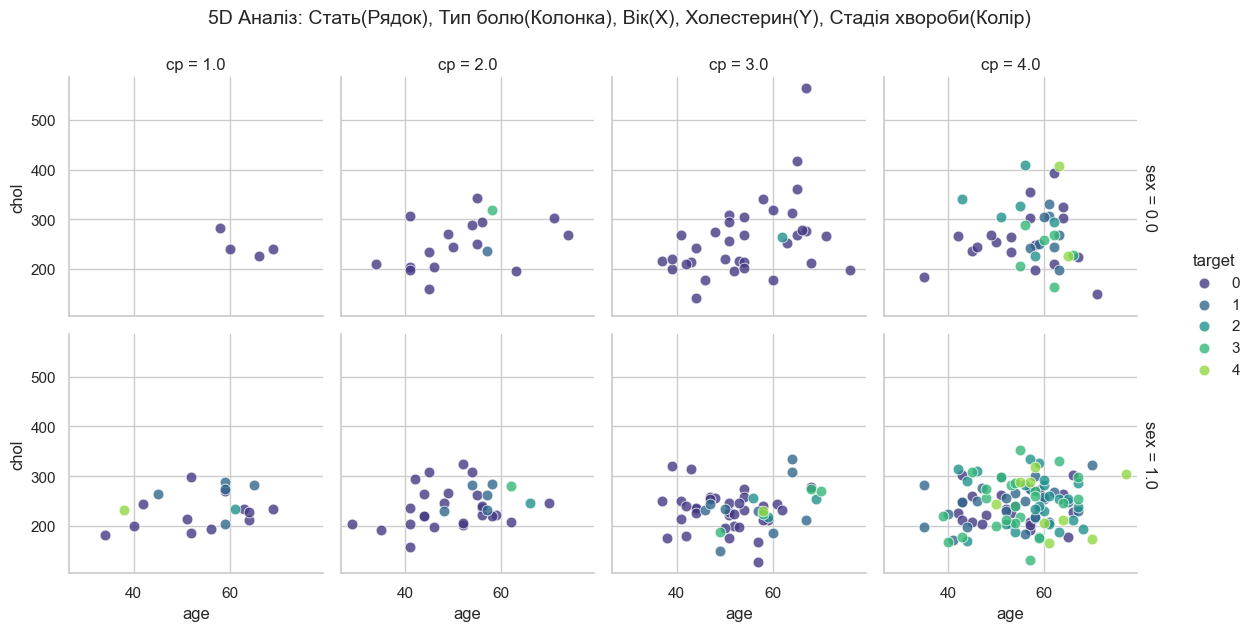

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Мистецтво багатовимірної візуалізації")
sns.set_theme(style="whitegrid")
print("\n1. Будуємо Pairplot")
cols_to_plot = ['age', 'trestbps', 'chol', 'thalach', 'target']
sns.pairplot(df_clean[cols_to_plot], hue='target', palette='husl', corner=True)
plt.suptitle("Матриця взаємозв'язків (Pairplot)", y=1.02, fontsize=16)
plt.show()
print("\n2. Будуємо 4D Scatter Plot")
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_clean, 
    x='age', 
    y='thalach', 
    hue='target', 
    size='chol',       
    sizes=(20, 300),   
    alpha=0.7, 
    palette='Set1'
)
plt.title('4D Аналіз: Вік (X), Пульс (Y), Стадія хвороби (Колір), Холестерин (Розмір точок)', fontsize=15)
plt.xlabel("Вік (age)")
plt.ylabel("Макс. пульс (thalach)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()
print("\n3. Будуємо 5D FacetGrid")
g = sns.FacetGrid(df_clean, col="cp", row="sex", hue="target", palette="viridis", margin_titles=True)
g.map_dataframe(sns.scatterplot, x="age", y="chol", alpha=0.8, s=60)
g.add_legend()
g.fig.suptitle('5D Аналіз: Стать(Рядок), Тип болю(Колонка), Вік(X), Холестерин(Y), Стадія хвороби(Колір)', y=1.05, fontsize=14)
plt.show()

## Завдання 6. Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.


Фінальні корисні графіки для аналізу


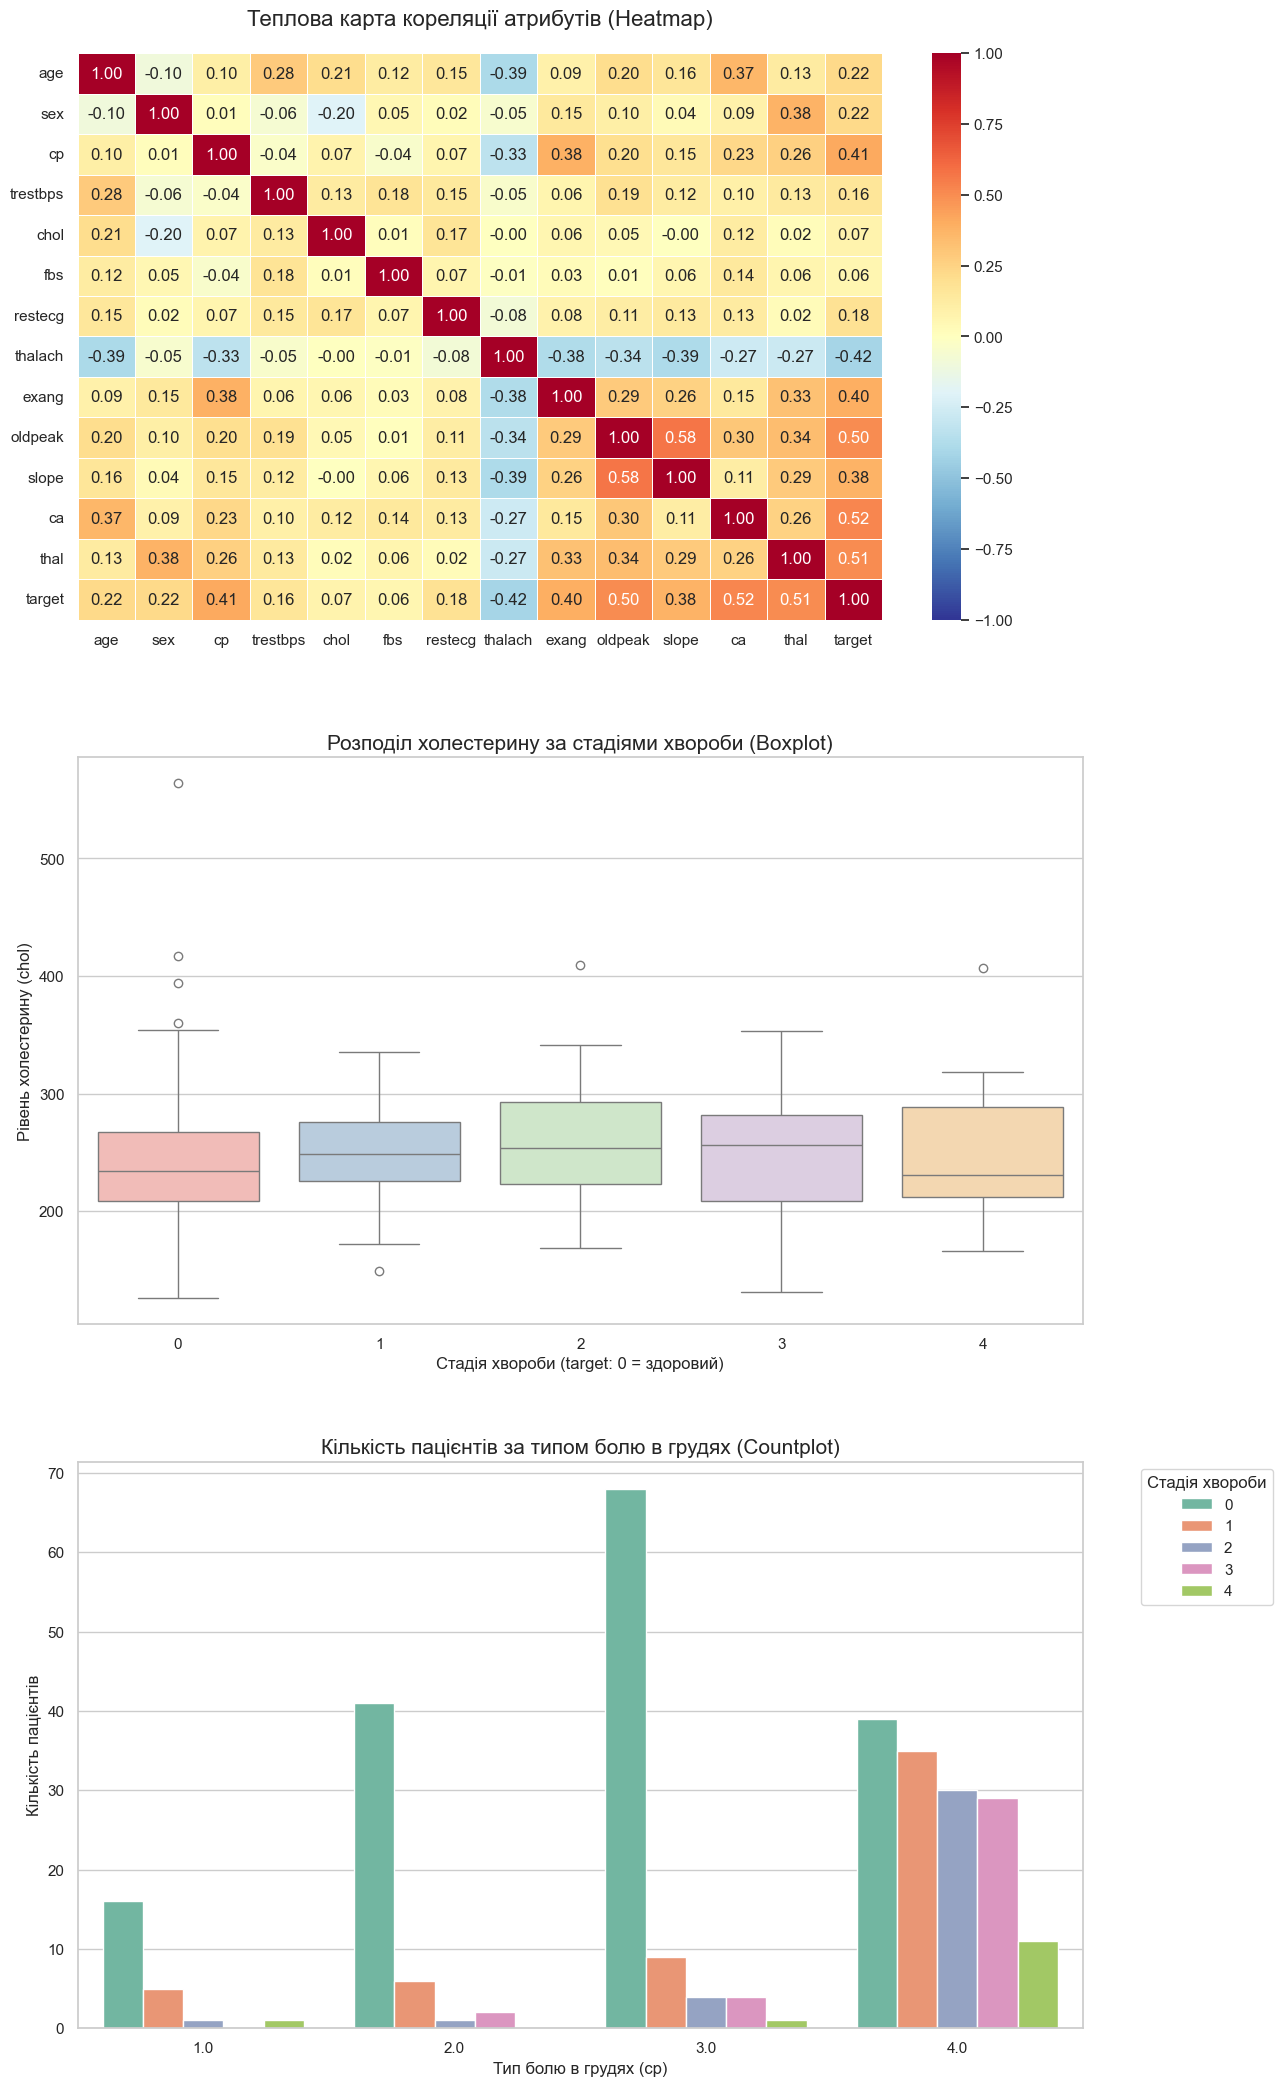

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Фінальні корисні графіки для аналізу")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 22))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Теплова карта кореляції атрибутів (Heatmap)", fontsize=16, pad=20)
sns.boxplot(data=df_clean, x='target', y='chol', hue='target', palette='Pastel1', legend=False, ax=axes[1])
axes[1].set_title("Розподіл холестерину за стадіями хвороби (Boxplot)", fontsize=15)
axes[1].set_xlabel("Стадія хвороби (target: 0 = здоровий)")
axes[1].set_ylabel("Рівень холестерину (chol)")
sns.countplot(data=df_clean, x='cp', hue='target', palette='Set2', ax=axes[2])
axes[2].set_title("Кількість пацієнтів за типом болю в грудях (Countplot)", fontsize=15)
axes[2].set_xlabel("Тип болю в грудях (cp)")
axes[2].set_ylabel("Кількість пацієнтів")
axes[2].legend(title="Стадія хвороби", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(pad=4.0)
plt.show()